# SIT307 11.1HD — Machine Learning Mini Research

Saatvik Sharma (225158822) · Deakin University · SIT307

Reproducing *An efficient stacking-based ensemble technique for early heart
attack prediction* and evaluating DS-Stack on distinct records.

## Setup and execution

Save this notebook with its existing filename and run the cells in order.
Setup installs missing packages and restores the embedded data and saved scores.
Only package installation needs internet access. Python 3.14 was used here.

`RERUN_EXPERIMENTS = False` loads saved CV scores and runs the remaining checks.
Set it to `True` to retrain everything; allow about 25–35 minutes on two workers.
The notebook creates local `data/`, `results/` and `figures/` folders.

In [1]:
import importlib.util
import os
import subprocess
import sys

# Limit numerical-library threads before importing NumPy or scikit-learn.
thread_variables = [
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
]
for variable_name in thread_variables:
    os.environ[variable_name] = "1"

os.environ["MPLBACKEND"] = "module://matplotlib_inline.backend_inline"
N_JOBS = 2
SEED = 42
RERUN_EXPERIMENTS = False

package_requirements = {
    "numpy": ("numpy", "2.5.3"),
    "pandas": ("pandas", "3.0.6"),
    "matplotlib": ("matplotlib", "3.11.2"),
    "scikit-learn": ("sklearn", "1.9.1"),
    "scipy": ("scipy", "1.18.1"),
    "seaborn": ("seaborn", "0.13.2"),
    "xgboost": ("xgboost", "3.4.1"),
    "joblib": ("joblib", "1.6.0"),
}
missing_packages = []
for package_name, (module_name, tested_version) in package_requirements.items():
    if importlib.util.find_spec(module_name) is None:
        missing_packages.append(f"{package_name}=={tested_version}")

if missing_packages:
    install_command = [sys.executable, "-m", "pip", "install"]
    subprocess.run(install_command + missing_packages, check=True)

print("Retrain every experiment:", RERUN_EXPERIMENTS)

Retrain every experiment: False


The fixed seed makes random choices repeatable. Two workers limit CPU use, and
`RERUN_EXPERIMENTS = False` uses saved experiment scores where available.


### Restore the embedded files

In [2]:
import hashlib
import json
from pathlib import Path

notebook_name = "SIT307-11.1HD-analysis.ipynb"
notebook_path = Path.cwd() / notebook_name
if not notebook_path.exists():
    notebook_path = Path.cwd() / "code" / notebook_name
if not notebook_path.exists():
    raise FileNotFoundError("Run beside the saved notebook file.")

project_folder = notebook_path.parent
with notebook_path.open(encoding="utf-8") as notebook_file:
    notebook_document = json.load(notebook_file)

embedded_files = notebook_document["metadata"]["standalone_assets"]
for relative_path, embedded_file in embedded_files.items():
    destination = project_folder / relative_path
    destination.parent.mkdir(parents=True, exist_ok=True)
    content = embedded_file["text"].encode("utf-8")
    actual_hash = hashlib.sha256(content).hexdigest()
    if actual_hash != embedded_file["sha256"]:
        raise ValueError(f"Embedded file failed its hash check: {relative_path}")

    # Existing results are kept; only missing files are restored.
    if not destination.exists():
        destination.write_bytes(content)

DATA = project_folder / "data"
RESULTS = project_folder / "results"
FIGURES = project_folder / "figures"
FIGURES.mkdir(exist_ok=True)

The datasets and cached scores are stored inside this notebook. This cell checks their
contents and restores missing local files, leaving existing files in place.


### Imports and experiment settings

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from IPython.display import display
from joblib import Parallel, delayed
from scipy.stats import wilcoxon
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.experimental import enable_iterative_imputer  # Enables this imputer.
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

FEATURES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal",
]
NUMERIC = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
NOMINAL = ["cp", "restecg", "slope", "thal"]
BINARY = ["sex", "fbs", "exang"]
METRICS = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
CLASS_LABELS = ["0 = disease", "1 = no disease"]
BOX_COLOR = "#8FB3D9"
ACCENT = "#C44E52"

PAPER = pd.DataFrame(
    {
        "Accuracy": [0.8439, 0.8439, 0.8585, 0.9268, 0.9268, 0.9073, 0.9853],
        "Precision": [0.8196, 0.8250, 0.8648, 0.9702, 0.9130, 0.9174, 1.0000],
        "Recall": [0.9090, 0.9000, 0.8727, 0.8909, 0.9545, 0.9090, 0.9727],
        "F1": [0.8620, 0.8608, 0.8687, 0.9289, 0.9333, 0.9132, 0.9861],
        "AUC": [0.9204, 0.9185, 0.9304, 0.9702, 0.9734, 0.9830, 0.9880],
    },
    index=["LR", "NB", "KNN", "DT", "RF", "XGB", "Stacking"],
)

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.titlesize": 13,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "savefig.dpi": 200,
        "savefig.bbox": "tight",
    }
)
pd.set_option("display.precision", 4)

The imports cover data handling, models, evaluation and plotting. The feature lists and
published scores are defined once so later experiments use the same reference values.


In [4]:
def saved_or_train(filename, train_experiment, **read_options):
    """Load saved scores, or train and save them when requested."""
    result_path = RESULTS / filename
    if result_path.exists() and not RERUN_EXPERIMENTS:
        return pd.read_csv(result_path, **read_options)

    print("Training experiment:", filename, flush=True)
    experiment_scores = train_experiment()
    experiment_scores.to_csv(result_path, index=False)
    return experiment_scores

`saved_or_train` loads a result file when one is available. Otherwise, or when rerunning
is enabled, it trains the experiment and saves the new scores.


## Part 1 — Understanding and checking the data

The dataset has 1,025 rows and 13 features. I first check its values, source and
repeated records, since copies in both training and test data can inflate scores.

### 1.1 Data-loading functions

In [5]:
def load_kaggle(dedup=False):
    """Read the embedded Kaggle file, optionally removing exact duplicates."""
    heart_records = pd.read_csv(DATA / "heart.csv")
    if dedup:
        heart_records = heart_records.drop_duplicates().reset_index(drop=True)
    return heart_records[FEATURES], heart_records["target"]


def load_uci(site):
    """Read a hospital file and map its codes to the Kaggle encoding."""
    hospital_records = pd.read_csv(
        DATA / f"uci_{site}.data",
        header=None,
        names=FEATURES + ["num"],
        na_values="?",
    )
    hospital_records["cp"] = hospital_records["cp"].map(
        {1: 3, 2: 1, 3: 2, 4: 0}
    )
    hospital_records["slope"] = hospital_records["slope"].map(
        {1: 2, 2: 1, 3: 0}
    )
    hospital_records["thal"] = hospital_records["thal"].map(
        {3: 2, 6: 1, 7: 3}
    )
    # A zero here means the measurement was not recorded.
    hospital_records.loc[hospital_records["chol"] == 0, "chol"] = np.nan
    hospital_records.loc[
        hospital_records["trestbps"] == 0, "trestbps"
    ] = np.nan
    hospital_records["target"] = (hospital_records["num"] == 0).astype(int)
    return hospital_records[FEATURES], hospital_records["target"]

`load_kaggle` reads the main CSV and can remove duplicates. `load_uci` loads a hospital
file and maps its categories and target to the same coding as the Kaggle file.


### 1.2 Loading the original file

In [6]:
X, y = load_kaggle()
heart_records = X.assign(target=y)
print("Shape:", heart_records.shape)
print("Class counts:", y.value_counts().to_dict())
heart_records.describe().T[["min", "max", "mean"]]

Shape: (1025, 14)
Class counts: {1: 526, 0: 499}


,min,max,mean
age,29.0,77.0,54.4341
sex,0.0,1.0,0.6956
cp,0.0,3.0,0.9424
trestbps,94.0,200.0,131.6117
chol,126.0,564.0,246.0000
fbs,0.0,1.0,0.1493
restecg,0.0,2.0,0.5298
thalach,71.0,202.0,149.1141
exang,0.0,1.0,0.3366
oldpeak,0.0,6.2,1.0715


There are 1,025 rows, with 13 input features and one target column. The summary checks
the value ranges before any models are fitted.


### 1.3 Invalid codes and missing values

In [7]:
invalid_value_counts = pd.Series(
    {
        "ca = 4": int((heart_records["ca"] == 4).sum()),
        "thal = 0": int((heart_records["thal"] == 0).sum()),
        "Explicit missing values": int(heart_records.isna().sum().sum()),
    },
    name="Count",
)
invalid_value_counts

ca = 4                     18
thal = 0                    7
Explicit missing values     0
Name: Count, dtype: int64

There are 18 rows with `ca=4` and seven with `thal=0`, even though no values are
explicitly missing. These codes fall outside the paper’s stated ranges, so I treat them
as missing and fill them using training data.


### 1.4 Repeated records

In [8]:
unique_record_count = len(heart_records.drop_duplicates())
print("Duplicate rows:", heart_records.duplicated().sum())
print("Distinct records:", unique_record_count)
record_copy_counts = heart_records.groupby(list(heart_records.columns)).size()

Duplicate rows: 723
Distinct records: 302


Removing exact repeats leaves 302 distinct records and 723 duplicate rows. There are no
patient IDs, so I cannot confirm that the distinct records represent separate people.


### 1.5 Checking the hospital and target coding

In [9]:
cleveland_records = pd.read_csv(
    DATA / "uci_cleveland.data",
    header=None,
    names=FEATURES + ["num"],
    na_values="?",
)
matching_features = [
    "age", "sex", "trestbps", "chol", "fbs", "thalach", "exang", "oldpeak"
]
matched_records = heart_records.drop_duplicates().merge(
    cleveland_records,
    on=matching_features,
    suffixes=("", "_uci"),
)
matched_count = matched_records[matching_features].drop_duplicates().shape[0]
print(
    "Unique Kaggle rows matched to Cleveland:",
    matched_count,
    "of",
    unique_record_count,
)
target_comparison = pd.crosstab(
    matched_records["target"],
    matched_records["num"],
    rownames=["Kaggle target"],
    colnames=["UCI num (0 = no disease)"],
)
display(target_comparison)
display(pd.crosstab(matched_records["cp"], matched_records["cp_uci"]))

Unique Kaggle rows matched to Cleveland: 302 of 302


UCI num (0 = no disease),0,1,2,3,4
Kaggle target,,,,,
0,0,54,36,35,13
1,164,0,0,0,0


cp_uci,1.0,2.0,3.0,4.0
cp,,,,
0,0,0,0,143
1,0,50,0,0
2,0,0,86,0
3,23,0,0,0


All 302 distinct records match Cleveland on the eight fields checked here. The target
comparison shows that `target=1` means no disease, which is the positive class for
precision, recall and F1; the chest-pain codes also differ between files.


### 1.6 Train/test overlap

In [10]:
def seen_fraction(seed):
    """Measure how many test rows have an identical training copy."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )
    training_records = X_train.assign(target=y_train).to_numpy()
    test_records = X_test.assign(target=y_test).to_numpy()
    training_rows = set()
    for record in training_records:
        training_rows.add(tuple(record))
    overlaps = []
    for record in test_records:
        overlaps.append(tuple(record) in training_rows)
    return np.mean(overlaps)

overlap_fractions = []
for split_seed in range(100):
    overlap_fractions.append(seen_fraction(split_seed))
overlap_fractions = np.asarray(overlap_fractions)
print(
    "Test rows also found in training over 100 splits:",
    f"mean {overlap_fractions.mean():.3f},",
    f"min {overlap_fractions.min():.3f},",
    f"max {overlap_fractions.max():.3f}",
)
pd.DataFrame({"seen_fraction": overlap_fractions}).to_csv(
    RESULTS / "leakage_fraction.csv", index=False
)

Test rows also found in training over 100 splits: mean 0.976, min 0.912, max 1.000


Across my 100 random 80:20 splits, an average of 97.6% of test rows have an identical
training copy. This measures overlap in my reproduction; the paper does not describe
duplicate handling, and I cannot confirm its exact split.


### 1.7 Showing the duplicate pattern

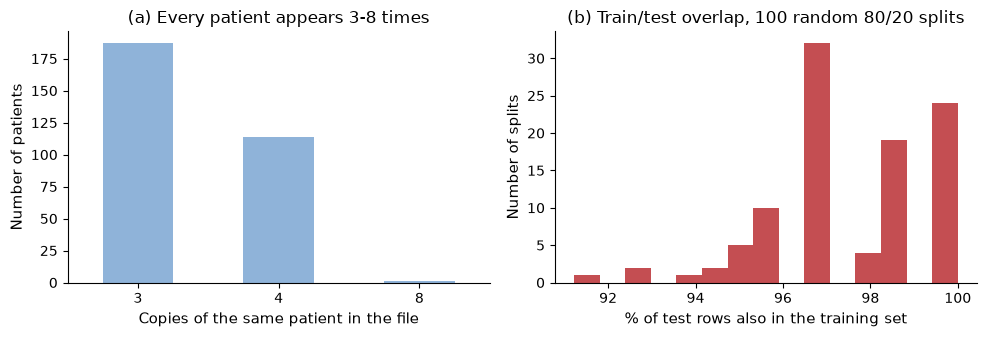

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
record_copy_counts.value_counts().sort_index().plot.bar(ax=ax[0], color=BOX_COLOR, rot=0)
ax[0].set_xlabel("Copies of the same patient in the file")
ax[0].set_ylabel("Number of patients")
ax[0].set_title("(a) Every patient appears 3-8 times")
ax[1].hist(overlap_fractions * 100, bins=15, color=ACCENT)
ax[1].set_xlabel("% of test rows also in the training set")
ax[1].set_ylabel("Number of splits")
ax[1].set_title("(b) Train/test overlap, 100 random 80/20 splits")
plt.tight_layout()
plt.savefig(FIGURES / "fig_duplicates_leakage.png")
plt.show()

Most distinct records appear three or four times; one appears eight times. The second
plot shows how often copies cross the training/test boundary, which can make performance
on new records look better than it is. These counts refer to records, not verified
patient identities.


## Part 2 — Reproducing the published models

I reproduce all six learners and five-fold stacking. The paper omits its seed,
classifier settings and meta-classifier, so I use seed 42, library defaults
and logistic regression as the meta-classifier. Its 205-row confusion matrix
supports an 80:20 split. These assumptions prevent an exact replication claim.

In [12]:
X, y = load_kaggle()
ORDER = ["LR", "NB", "KNN", "DT", "RF", "XGB", "Stacking"]


def all_models(seed=SEED):
    """Create preprocessed base learners and the stacking baseline."""
    models = {}
    for name, classifier in base_models(seed).items():
        models[name] = with_prep(classifier)
    models["Stacking"] = paper_stacking(seed)
    return models

This comparison keeps the original rows, including duplicates, to reproduce the paper’s
setting. All six base models and stacking use the same split.


### 2.1 Preprocessing, base learners and stacking

In [13]:
class InvalidCodesToNaN(BaseEstimator, TransformerMixin):
    """Replace invalid ca and thal codes with missing values."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        cleaned_features = pd.DataFrame(X, columns=FEATURES).copy()
        cleaned_features.loc[cleaned_features["ca"] > 3, "ca"] = np.nan
        cleaned_features.loc[cleaned_features["thal"] < 1, "thal"] = np.nan
        return cleaned_features

class RoundCategorical(BaseEstimator, TransformerMixin):
    """Round imputed category codes and keep them within valid ranges."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        rounded_features = pd.DataFrame(X, columns=FEATURES).copy()
        category_ranges = {
            "ca": (0, 3),
            "thal": (1, 3),
            "cp": (0, 3),
            "slope": (0, 2),
            "restecg": (0, 2),
        }
        for column, (minimum, maximum) in category_ranges.items():
            rounded_column = rounded_features[column].round()
            rounded_features[column] = rounded_column.clip(minimum, maximum)
        for column in BINARY:
            rounded_features[column] = rounded_features[column].round().clip(0, 1)
        return rounded_features

Invalid codes become missing values. After regression imputation, categorical values are
rounded and clipped so they stay within the allowed codes.


In [14]:
def paper_preprocessor():
    """Apply the paper's imputation, code rounding and scaling."""
    regression_imputer = IterativeImputer(
        estimator=LinearRegression(),
        random_state=SEED,
    )
    return Pipeline(
        [
            ("invalid", InvalidCodesToNaN()),
            ("impute", regression_imputer),
            ("round", RoundCategorical()),
            ("scale", StandardScaler()),
        ]
    )

The preprocessing pipeline fills missing values, restores valid category codes and
scales the features. Fitting it inside the training pipeline keeps the held-out test
data out of these steps.


In [15]:
def base_models(seed=SEED):
    """Create the paper's six learners with the reproduction defaults."""
    return {
        "LR": LogisticRegression(max_iter=1000, random_state=seed),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(),
        "DT": DecisionTreeClassifier(random_state=seed),
        "RF": RandomForestClassifier(random_state=seed),
        "XGB": XGBClassifier(
            eval_metric="logloss",
            random_state=seed,
            n_jobs=1,
        ),
    }

def with_prep(model, prep=paper_preprocessor):
    """Fit preprocessing and the classifier as one training pipeline."""
    return Pipeline([("prep", prep()), ("clf", model)])

def paper_stacking(seed=SEED, meta=None):
    """Combine six learners using five-fold stacking and an LR meta-model."""
    estimators = list(base_models(seed).items())
    if meta is None:
        meta = LogisticRegression(max_iter=1000)
    inner_cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    stacking_model = StackingClassifier(
        estimators=estimators,
        final_estimator=meta,
        cv=inner_cv,
        stack_method="predict_proba",
        n_jobs=1,
    )
    return with_prep(stacking_model)

The six learners are LR, NB, KNN, DT, RF and XGBoost. Stacking uses five-fold
predictions to train a logistic-regression model that combines their probabilities.


In [16]:
def scores(y_true, y_pred, y_prob):
    """Calculate classification metrics for target 1, the no-disease class."""
    matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
    true_negative, false_positive, false_negative, true_positive = matrix.ravel()
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "Specificity": true_negative / (true_negative + false_positive),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }

def fit_score(model, X_train, y_train, X_test, y_test):
    """Fit a fresh model and return its scores, probabilities and classes."""
    # Clone keeps the supplied model unfitted.
    fitted_model = clone(model).fit(X_train, y_train)
    # Column 1 is the no-disease probability.
    probabilities = fitted_model.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    model_scores = scores(y_test, predictions, probabilities)
    return model_scores, fitted_model, probabilities, predictions

These functions fit a model and calculate accuracy, precision, recall, F1 and AUC, plus
specificity and MCC. Here, the positive class is no disease, not a positive medical
diagnosis.


### 2.2 One 80:20 split: fit and score

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

single_split_scores = {}
fitted_models = {}
prediction_probabilities = {}
predicted_classes = {}
for name, model in all_models().items():
    model_scores, fitted_model, probabilities, predictions = fit_score(
        model, X_train, y_train, X_test, y_test
    )
    single_split_scores[name] = model_scores
    fitted_models[name] = fitted_model
    prediction_probabilities[name] = probabilities
    predicted_classes[name] = predictions

single_split_scores = pd.DataFrame(single_split_scores).T.loc[ORDER]
single_split_scores.to_csv(RESULTS / "p1_single_split.csv")
single_split_scores

,Accuracy,Precision,Recall,F1,AUC,Specificity,MCC
LR,0.8146,0.7731,0.8932,0.8288,0.9000,0.7353,0.6368
NB,0.8000,0.7541,0.8932,0.8178,0.8846,0.7059,0.6102
KNN,0.8293,0.7931,0.8932,0.8402,0.9490,0.7647,0.6637
DT,0.9854,1.0000,0.9709,0.9852,0.9854,1.0000,0.9712
RF,0.9854,1.0000,0.9709,0.9852,1.0000,1.0000,0.9712
XGB,0.9854,1.0000,0.9709,0.9852,0.9837,1.0000,0.9712
Stacking,0.9854,1.0000,0.9709,0.9852,1.0000,1.0000,0.9712


Every model uses the same 80:20 split with seed 42. Keeping the split fixed makes the
single-run comparison consistent, although duplicate overlap remains.


### 2.3 Comparison with the published table

In [18]:
comparison = pd.concat(
    {"Paper": PAPER[METRICS], "Ours": single_split_scores[METRICS]},
    axis=1,
)
comparison = comparison.swaplevel(axis=1).sort_index(axis=1, level=0)[METRICS]
comparison.to_csv(RESULTS / "p1_single_vs_paper.csv")
comparison

Accuracy         Precision          Recall              F1          \
             Ours   Paper      Ours   Paper    Ours   Paper    Ours   Paper   
LR         0.8146  0.8439    0.7731  0.8196  0.8932  0.9090  0.8288  0.8620   
NB         0.8000  0.8439    0.7541  0.8250  0.8932  0.9000  0.8178  0.8608   
KNN        0.8293  0.8585    0.7931  0.8648  0.8932  0.8727  0.8402  0.8687   
DT         0.9854  0.9268    1.0000  0.9702  0.9709  0.8909  0.9852  0.9289   
RF         0.9854  0.9268    1.0000  0.9130  0.9709  0.9545  0.9852  0.9333   
XGB        0.9854  0.9073    1.0000  0.9174  0.9709  0.9090  0.9852  0.9132   
Stacking   0.9854  0.9853    1.0000  1.0000  0.9709  0.9727  0.9852  0.9861   

             AUC          
            Ours   Paper  
LR        0.9000  0.9204  
NB        0.8846  0.9185  
KNN       0.9490  0.9304  
DT        0.9854  0.9702  
RF        1.0000  0.9734  
XGB       0.9837  0.9830  
Stacking  1.0000  0.9880

Stacking reaches 98.54% accuracy, close to the paper’s 98.53%, with three errors among
205 test rows. Other scores and the class balance differ, so matching accuracy does not
mean an exact replication.


### 2.4 Confusion matrices

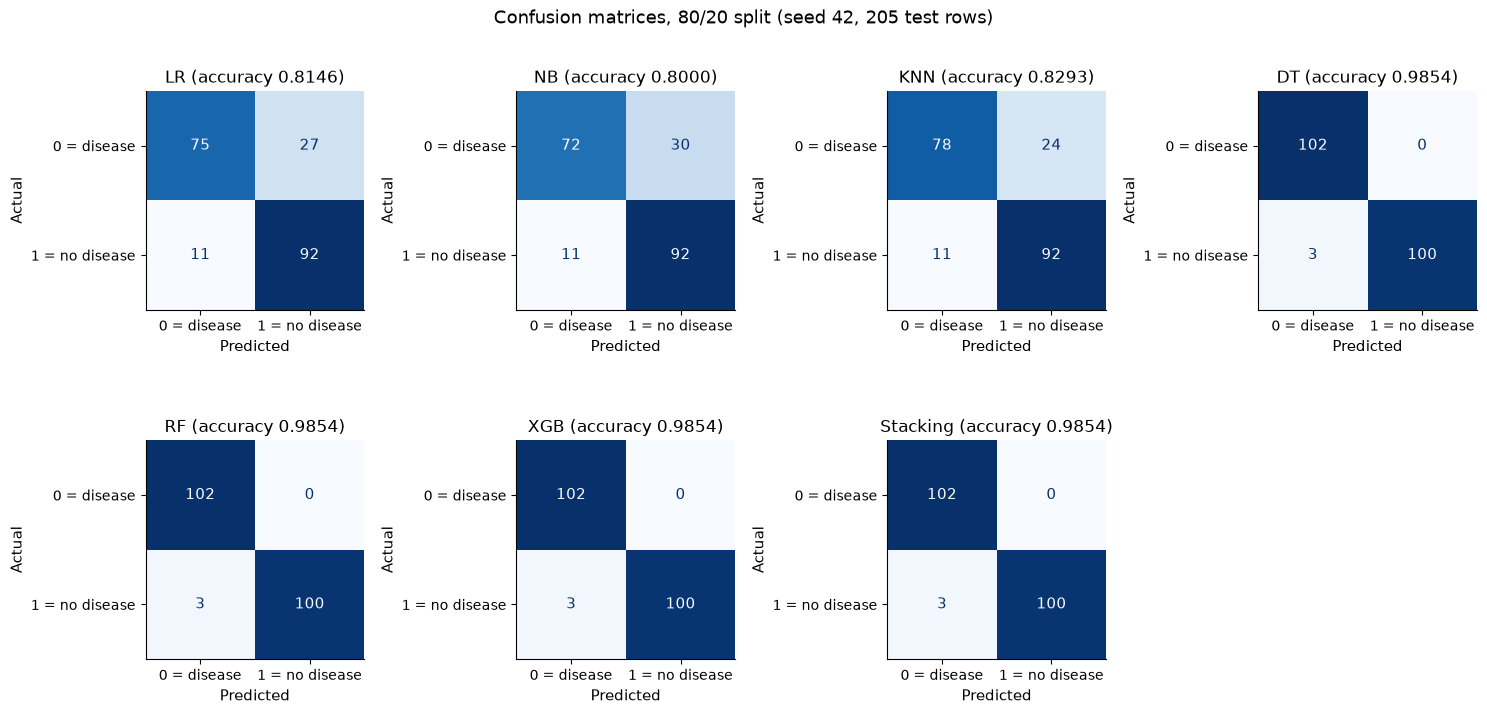

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))
for ax, name in zip(axes.ravel(), ORDER):
    matrix = confusion_matrix(y_test, predicted_classes[name])
    matrix_display = ConfusionMatrixDisplay(matrix, display_labels=CLASS_LABELS)
    matrix_display.plot(ax=ax, colorbar=False, cmap="Blues")
    accuracy = single_split_scores.loc[name, "Accuracy"]
    ax.set_title(f"{name} (accuracy {accuracy:.4f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
axes.ravel()[-1].axis("off")
fig.suptitle("Confusion matrices, 80/20 split (seed 42, 205 test rows)")
plt.tight_layout()
plt.savefig(FIGURES / "p1_confusion_matrices.png")
plt.show()

Diagonal entries are correct predictions; off-diagonal entries are mistakes. The labels
matter here: class 0 means disease and class 1 means no disease.


### 2.5 ROC curves

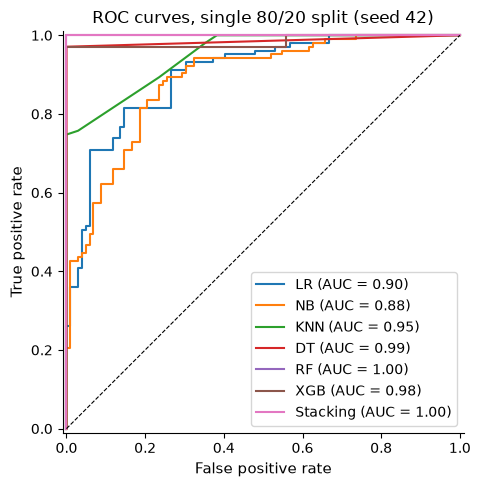

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
for name in ORDER:
    RocCurveDisplay.from_predictions(
        y_test, prediction_probabilities[name], name=name, ax=ax
    )
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves, single 80/20 split (seed 42)")
plt.tight_layout()
plt.savefig(FIGURES / "p1_roc_single.png")
plt.show()

ROC curves compare true-positive and false-positive rates across thresholds. Stacking
reaches AUC 1.0 on this split, but duplicate overlap limits what that says about unseen
records.


### 2.6 Feature importance

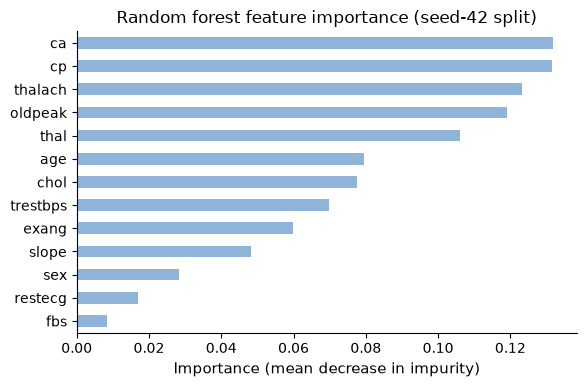

In [21]:
random_forest = fitted_models["RF"].named_steps["clf"]
feature_importance = pd.Series(
    random_forest.feature_importances_, index=FEATURES
).sort_values()
feature_importance.to_csv(
    RESULTS / "p1_rf_importance.csv", header=["importance"]
)
ax = feature_importance.plot.barh(
    figsize=(6, 4),
    color=BOX_COLOR,
    title="Random forest feature importance (seed-42 split)",
)
ax.set_xlabel("Importance (mean decrease in impurity)")
plt.tight_layout()
plt.savefig(FIGURES / "p1_feature_importance.png")
plt.show()

The bars show how much each feature contributes to the fitted random forest’s impurity-
based importance. This describes the model, not a causal effect on heart disease.


### 2.7 Repeating the split 100 times

In [22]:
def run_split(seed):
    """Score each model and separate seen from unseen test records."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )
    training_rows = set()
    for record in X_train.assign(target=y_train).to_numpy():
        training_rows.add(tuple(record))
    seen_records = []
    for record in X_test.assign(target=y_test).to_numpy():
        seen_records.append(tuple(record) in training_rows)
    seen_records = np.asarray(seen_records)
    unseen_records = ~seen_records
    result_rows = []
    for name, model in all_models(seed).items():
        model_scores, _, _, predictions = fit_score(
            model, X_train, y_train, X_test, y_test
        )
        correct_predictions = predictions == y_test.to_numpy()
        if unseen_records.any():
            unseen_accuracy = correct_predictions[unseen_records].mean()
        else:
            unseen_accuracy = np.nan
        model_scores.update(
            model=name,
            seed=seed,
            acc_seen=correct_predictions[seen_records].mean(),
            acc_unseen=unseen_accuracy,
            n_unseen=int(unseen_records.sum()),
        )
        result_rows.append(model_scores)
    return result_rows


def train_repeated_splits():
    """Run 100 seeded splits and collect one row per model per split."""
    # delayed schedules each split on one of the two workers.
    split_results = Parallel(n_jobs=N_JOBS)(
        delayed(run_split)(seed) for seed in range(100)
    )
    result_rows = []
    for split_rows in split_results:
        result_rows.extend(split_rows)
    return pd.DataFrame(result_rows)


repeated_scores = saved_or_train(
    "p1_repeated_splits_raw.csv", train_repeated_splits
)
repeated_summary = repeated_scores.groupby("model")[METRICS].agg(
    ["mean", "std"]
).loc[ORDER]
repeated_summary.to_csv(RESULTS / "p1_repeated_splits_summary.csv")
repeated_summary

Accuracy         Precision          Recall              F1          \
             mean     std      mean     std    mean     std    mean     std   
model                                                                         
LR         0.8580  0.0185    0.8321  0.0302  0.9084  0.0241  0.8681  0.0189   
NB         0.8314  0.0215    0.8133  0.0309  0.8737  0.0302  0.8420  0.0228   
KNN        0.8457  0.0244    0.8454  0.0379  0.8589  0.0358  0.8513  0.0251   
DT         0.9965  0.0076    0.9971  0.0089  0.9962  0.0109  0.9966  0.0076   
RF         0.9971  0.0078    0.9974  0.0083  0.9969  0.0100  0.9971  0.0078   
XGB        0.9968  0.0077    0.9969  0.0105  0.9969  0.0097  0.9968  0.0075   
Stacking   0.9974  0.0067    0.9974  0.0083  0.9975  0.0082  0.9974  0.0067   

             AUC          
            mean     std  
model                     
LR        0.9294  0.0151  
NB        0.9138  0.0174  
KNN       0.9544  0.0133  
DT        0.9966  0.0076  
RF        0.9999  0.0004  
XGB       0.9995  0.0023  
Stacking  0.9998  0.0012

Repeating the experiment with 100 seeds shows how scores change with the split. It does
not remove duplicate overlap, so this is a stability check rather than an independent
test on new records.


### 2.8 Variation across splits

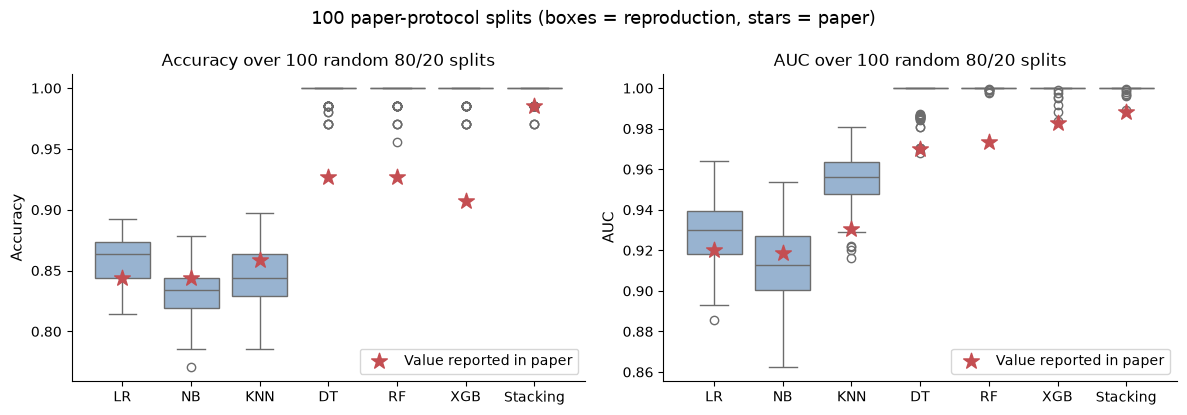

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, metric in zip(axes, ["Accuracy", "AUC"]):
    sns.boxplot(
        data=repeated_scores,
        x="model",
        y=metric,
        order=ORDER,
        ax=ax,
        color=BOX_COLOR,
    )
    ax.scatter(
        range(len(ORDER)),
        PAPER.loc[ORDER, metric],
        color=ACCENT,
        marker="*",
        s=140,
        zorder=5,
        label="Value reported in paper",
    )
    ax.set_xlabel("")
    ax.set_title(f"{metric} over 100 random 80/20 splits")
    ax.legend(loc="lower right")
fig.suptitle("100 paper-protocol splits (boxes = reproduction, stars = paper)")
plt.tight_layout()
plt.savefig(FIGURES / "p1_repeated_boxplot.png")
plt.show()

The boxes show the spread of accuracy and AUC across the repeated splits. The stars mark
the paper’s scores, making it easier to see whether they fall near typical or unusually
high results.


### 2.9 Where the paper falls in the observed distribution

In [24]:
percentile_values = {}
for metric in METRICS:
    model_percentiles = []
    for model_name in ORDER:
        model_rows = repeated_scores[repeated_scores["model"] == model_name]
        reported_value = PAPER.loc[model_name, metric]
        percentile = (model_rows[metric] <= reported_value).mean() * 100
        model_percentiles.append(percentile)
    percentile_values[metric] = model_percentiles
paper_percentiles = pd.DataFrame(percentile_values, index=ORDER)
paper_percentiles.round(0)

,Accuracy,Precision,Recall,F1,AUC
LR,20.0,35.0,51.0,34.0,32.0
NB,67.0,65.0,82.0,81.0,59.0
KNN,64.0,70.0,68.0,73.0,5.0
DT,0.0,3.0,0.0,0.0,1.0
RF,0.0,0.0,1.0,0.0,0.0
XGB,0.0,0.0,0.0,0.0,0.0
Stacking,3.0,100.0,6.0,11.0,0.0


Each entry is the percentage of my runs that scored at or below the paper’s value. A
high percentile means the published score is near the upper end of my results.


### 2.10 Seen records versus unseen records

In [25]:
overlap_metrics = ["acc_seen", "acc_unseen", "n_unseen"]
seen_summary = repeated_scores.groupby("model")[overlap_metrics].mean()
seen_summary = seen_summary.loc[ORDER]
seen_summary.to_csv(RESULTS / "p1_seen_vs_unseen.csv")
seen_summary

,acc_seen,acc_unseen,n_unseen
model,,,
LR,0.8570,0.9162,4.94
NB,0.8301,0.8851,4.94
KNN,0.8452,0.8688,4.94
DT,1.0000,0.8658,4.94
RF,1.0000,0.8779,4.94
XGB,1.0000,0.8651,4.94
Stacking,1.0000,0.8822,4.94


Trees and stacking are perfect on seen records and weaker on unseen ones. Only about
five test rows per split are unseen, so those subgroup scores are uncertain.


### 2.11 Checking the choice of meta-classifier

In [26]:
meta_models = {
    "LR": LogisticRegression(max_iter=1000),
    "NB": GaussianNB(),
    "RF": RandomForestClassifier(random_state=SEED),
    "XGB": XGBClassifier(eval_metric="logloss", n_jobs=1, random_state=SEED),
}


def run_meta(seed):
    """Compare four meta-classifiers on one identical train/test split."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )
    result_rows = []
    for name, meta_model in meta_models.items():
        stacking_model = paper_stacking(seed, meta=meta_model)
        model_scores = fit_score(
            stacking_model, X_train, y_train, X_test, y_test
        )[0]
        model_scores.update(meta=name, seed=seed)
        result_rows.append(model_scores)
    return result_rows


summary_path = RESULTS / "p1_meta_ablation.csv"
if summary_path.exists() and not RERUN_EXPERIMENTS:
    meta_summary = pd.read_csv(summary_path, header=[0, 1], index_col=0)
else:
    print("Training meta-classifier comparison", flush=True)
    split_results = Parallel(n_jobs=N_JOBS)(
        delayed(run_meta)(seed) for seed in range(30)
    )
    result_rows = []
    for split_rows in split_results:
        result_rows.extend(split_rows)
    meta_scores = pd.DataFrame(result_rows)
    meta_summary = meta_scores.groupby("meta")[METRICS].agg(["mean", "std"])
    meta_summary.to_csv(summary_path)
meta_summary

Accuracy         Precision          Recall              F1          \
         mean     std      mean     std    mean     std    mean     std   
meta                                                                      
LR     0.9980  0.0051    0.9971  0.0090  0.9991  0.0048  0.9981  0.0050   
NB     0.9976  0.0067    0.9962  0.0123  0.9991  0.0048  0.9976  0.0066   
RF     0.9961  0.0085    0.9943  0.0156  0.9981  0.0072  0.9961  0.0084   
XGB    0.9966  0.0074    0.9961  0.0102  0.9971  0.0087  0.9966  0.0074   

         AUC          
        mean     std  
meta                  
LR    0.9998  0.0009  
NB    0.9986  0.0043  
RF    0.9989  0.0041  
XGB   0.9988  0.0055

Changing the meta-classifier checks whether the choice of combining model explains the
result. The four choices give similar mean accuracy under this duplicate-heavy protocol.


### 2.12 Recalculating metrics from the paper’s confusion matrix

In [27]:
tn, fp, fn, tp = 95, 0, 3, 107
mcc = (tp * tn - fp * fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
check = pd.DataFrame({
    "reported": [0.9853, 0.9861, 1.0000, 0.9727, 0.9861, 1.0000],
    "from Fig. 5": [(tp + tn) / 205, tn / (tn + fp), tp / (tp + fp), tp / (tp + fn),
                    2 * tp / (2 * tp + fp + fn), mcc]},
    index=["Accuracy", "Specificity", "Precision", "Recall/Sensitivity", "F1", "MCC"])
check.to_csv(RESULTS / "p1_paper_consistency.csv")
display(check.round(4))
paper_metric_table = pd.DataFrame({
    "Accuracy": [0.8439, 0.8439, 0.8585, 0.9268, 0.9268, 0.9073, 0.9853],
    "Sensitivity": [0.8439, 0.8439, 0.8585, 0.9268, 0.9268, 0.9073, 0.9853],
    "Recall": [0.9090, 0.9, 0.8727, 0.8909, 0.9545, 0.9090, 0.9727],
    "F1": [0.8620, 0.8608, 0.8687, 0.9289, 0.9333, 0.9132, 0.9861],
    "Specificity": [0.8620, 0.8608, 0.8687, 0.9289, 0.9333, 0.9132, 0.9861],
    "Precision": [0.8196, 0.8250, 0.8648, 0.9702, 0.9130, 0.9174, 1.0],
    "MCC": [0.8196, 0.825, 0.8648, 0.9702, 0.9130, 0.9174, 1.0]}, index=ORDER)


column_pairs = [
    ("Sensitivity", "Accuracy"),
    ("Specificity", "F1"),
    ("MCC", "Precision"),
    ("Sensitivity", "Recall"),
]
column_matches = {}
for first_column, second_column in column_pairs:
    columns_match = (
        paper_metric_table[first_column] == paper_metric_table[second_column]
    ).all()
    column_matches[f"{first_column} = {second_column}"] = columns_match
display(pd.Series(column_matches, name="Columns match"))

,reported,from Fig. 5
Accuracy,0.9853,0.9854
Specificity,0.9861,1.0000
Precision,1.0000,1.0000
Recall/Sensitivity,0.9727,0.9727
F1,0.9861,0.9862
MCC,1.0000,0.9711


Sensitivity = Accuracy     True
Specificity = F1           True
MCC = Precision            True
Sensitivity = Recall      False
Name: Columns match, dtype: bool

Recalculating from the paper’s confusion matrix gives MCC about 0.971 and specificity
1.000, unlike its table. Some reported columns are also identical, which raises a
reporting-consistency issue.


## Part 3 — Proposed solution and evaluation without duplicate overlap

All models use the same five repetitions of ten-fold CV after deduplication.
DS-Stack adds one-hot encoding, inner tuning and forward learner selection.
The outer test fold is held out from preprocessing and model selection.

In [28]:
X_unique, y_unique = load_kaggle(dedup=True)


def candidates():
    """Create baselines and ablations using the same outer folds."""
    models = {}
    for name, classifier in base_models().items():
        models[name] = with_prep(classifier)
    models["Paper stacking"] = paper_stacking()
    models["+ one-hot"] = DiversityStacking(tune=False, select=False)
    models["+ one-hot + tuning"] = DiversityStacking(tune=True, select=False)
    models["DS-Stack (proposed)"] = DiversityStacking(tune=True, select=True)
    return models

All candidates now use the 302 distinct records. The intermediate variants add one-hot
encoding and tuning before learner selection, helping separate the effects of those
changes.


### 3.1 How DS-Stack is implemented

In [29]:
def proposed_preprocessor():
    """Impute missing values and one-hot encode nominal categories."""
    encoder = ColumnTransformer(
        [
            ("num", StandardScaler(), NUMERIC),
            (
                "nom",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                NOMINAL,
            ),
            ("bin", "passthrough", BINARY),
        ]
    )
    regression_imputer = IterativeImputer(
        estimator=LinearRegression(),
        random_state=SEED,
    )
    return Pipeline(
        [
            ("invalid", InvalidCodesToNaN()),
            ("impute", regression_imputer),
            ("round", RoundCategorical()),
            ("encode", encoder),
        ]
    )

One-hot encoding represents nominal categories as separate indicators instead of
numerical amounts. Missing values are filled and numerical features are scaled within
each training fit.


In [30]:
class DiversityStacking(BaseEstimator, ClassifierMixin):
    """Tune base learners, select a useful subset, and stack their probabilities."""

    def __init__(
        self,
        n_iter=20,
        inner_folds=5,
        min_gain=0.001,
        seed=SEED,
        tune=True,
        select=True,
        prep=proposed_preprocessor,
    ):
        self.n_iter = n_iter
        self.inner_folds = inner_folds
        self.min_gain = min_gain
        self.seed = seed
        self.tune = tune
        self.select = select
        self.prep = prep

    def _meta(self):
        return LogisticRegression(C=1.0, max_iter=1000)

    def _oof_auc(self, probabilities, target, selected_columns, inner_cv):
        selected_probabilities = probabilities[:, selected_columns]
        meta_predictions = cross_val_predict(
            self._meta(),
            selected_probabilities,
            target,
            cv=inner_cv,
            method="predict_proba",
        )
        return roc_auc_score(target, meta_predictions[:, 1])

    def fit(self, X, y):
        target = np.asarray(y)
        inner_cv = StratifiedKFold(
            self.inner_folds,
            shuffle=True,
            random_state=self.seed,
        )
        self.names_ = []
        tuned_models = []
        for name, model in base_models(self.seed).items():
            model_pipeline = with_prep(model, self.prep)
            if self.tune:
                parameter_grid = {}
                for parameter_name, values in SEARCH_SPACES[name].items():
                    # Double underscores select the classifier parameter.
                    parameter_grid[f"clf__{parameter_name}"] = values
                search = RandomizedSearchCV(
                    model_pipeline,
                    parameter_grid,
                    n_iter=self.n_iter,
                    scoring="roc_auc",
                    cv=inner_cv,
                    random_state=self.seed,
                    n_jobs=1,
                )
                model_pipeline = search.fit(X, target).best_estimator_
            self.names_.append(name)
            tuned_models.append(model_pipeline)

        # Each row gets a prediction from a model that did not train on it.
        probability_columns = []
        for model in tuned_models:
            fold_predictions = cross_val_predict(
                clone(model), X, target, cv=inner_cv, method="predict_proba"
            )
            probability_columns.append(fold_predictions[:, 1])
        oof_probabilities = np.column_stack(probability_columns)

        if self.select:
            single_model_auc = []
            for column in range(oof_probabilities.shape[1]):
                learner_auc = roc_auc_score(target, oof_probabilities[:, column])
                single_model_auc.append(learner_auc)
            chosen_columns = [int(np.argmax(single_model_auc))]
            best_auc = self._oof_auc(
                oof_probabilities, target, chosen_columns, inner_cv
            )
            while len(chosen_columns) < oof_probabilities.shape[1]:
                candidate_auc = {}
                for column in range(oof_probabilities.shape[1]):
                    if column in chosen_columns:
                        continue
                    trial_columns = chosen_columns + [column]
                    candidate_auc[column] = self._oof_auc(
                        oof_probabilities, target, trial_columns, inner_cv
                    )
                best_column = max(candidate_auc, key=candidate_auc.get)
                next_auc = candidate_auc[best_column]
                if next_auc - best_auc < self.min_gain:
                    break
                chosen_columns.append(best_column)
                best_auc = next_auc
        else:
            chosen_columns = list(range(oof_probabilities.shape[1]))

        self.selected_ = []
        self.models_ = []
        for column in chosen_columns:
            self.selected_.append(self.names_[column])
            fitted_model = clone(tuned_models[column]).fit(X, target)
            self.models_.append(fitted_model)
        self.meta_ = self._meta().fit(
            oof_probabilities[:, chosen_columns], target
        )
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        probability_columns = []
        for model in self.models_:
            probability_columns.append(model.predict_proba(X)[:, 1])
        base_probabilities = np.column_stack(probability_columns)
        return self.meta_.predict_proba(base_probabilities)

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

ORDER = list(candidates())

DS-Stack tunes each learner using five inner folds and 20 sampled settings, then builds
out-of-fold predictions. It starts with the strongest individual AUC and adds a learner
only if combined validation AUC improves by at least 0.001. Logistic regression combines
the selected predictions. Inner selection scores can be optimistic, so final performance
is measured on outer test folds.


In [31]:
def corrected_ttest(first_scores, second_scores, n_train, n_test):
    """Compare paired scores using the Nadeau–Bengio variance correction."""
    from scipy import stats

    differences = np.asarray(first_scores) - np.asarray(second_scores)
    comparison_count = len(differences)
    sample_variance = differences.var(ddof=1)
    if sample_variance > 0:
        correction = 1 / comparison_count + n_test / n_train
        standard_error = np.sqrt(correction * sample_variance)
        t_statistic = differences.mean() / standard_error
    else:
        t_statistic = np.inf
    p_value = 2 * stats.t.sf(abs(t_statistic), df=comparison_count - 1)
    return t_statistic, p_value

This test compares paired fold scores and approximately adjusts for overlapping training
sets. Treating all 50 scores as independent would understate uncertainty.


### 3.2 Search spaces

In [32]:
SEARCH_SPACES = {
    "LR": {"C": np.logspace(-3, 2, 30)},
    "NB": {"var_smoothing": np.logspace(-11, -1, 30)},
    "KNN": {"n_neighbors": list(range(3, 41, 2)), "weights": ["uniform", "distance"],
            "p": [1, 2]},
    "DT": {"max_depth": [2, 3, 4, 5, 6, 8, None], "min_samples_leaf": [1, 3, 5, 10, 20],
           "criterion": ["gini", "entropy"]},
    "RF": {"n_estimators": [200, 400], "max_depth": [3, 4, 5, 7, None],
           "min_samples_leaf": [1, 3, 5, 10], "max_features": ["sqrt", 0.5]},
    "XGB": {"n_estimators": [100, 200, 400], "max_depth": [2, 3, 4],
            "learning_rate": [0.01, 0.03, 0.1], "subsample": [0.7, 1.0],
            "colsample_bytree": [0.5, 0.8, 1.0], "min_child_weight": [1, 3, 5]},
}

The search spaces list the parameter values each model may try. The limited search
controls training time; it does not guarantee the best possible settings.


### 3.3 Five repetitions of ten-fold CV

In [33]:
outer_cv = RepeatedStratifiedKFold(
    n_splits=10, n_repeats=5, random_state=SEED
)
folds = list(outer_cv.split(X_unique, y_unique))


def run_proposed_fold(fold_number, train_indices, test_indices):
    """Fit each candidate on the training part of one outer fold."""
    result_rows = []
    for name, model in candidates().items():
        model_scores, fitted_model, _, _ = fit_score(
            model,
            X_unique.iloc[train_indices],
            y_unique.iloc[train_indices],
            X_unique.iloc[test_indices],
            y_unique.iloc[test_indices],
        )
        selected_learners = getattr(fitted_model, "selected_", [])
        model_scores.update(
            model=name, fold=fold_number, selected="+".join(selected_learners)
        )
        result_rows.append(model_scores)
    return result_rows


def train_proposed_cv():
    """Collect all candidate scores over the 50 outer folds."""
    fold_results = Parallel(n_jobs=N_JOBS)(
        delayed(run_proposed_fold)(fold_number, train_indices, test_indices)
        for fold_number, (train_indices, test_indices) in enumerate(folds)
    )
    result_rows = []
    for fold_rows in fold_results:
        result_rows.extend(fold_rows)
    return pd.DataFrame(result_rows)


cv_scores = saved_or_train("p2_cv_raw.csv", train_proposed_cv)
assert cv_scores.groupby("model")["fold"].nunique().eq(50).all()
assert not cv_scores.duplicated(["model", "fold"]).any()
summary_metrics = METRICS + ["Specificity", "MCC"]
summary = cv_scores.groupby("model")[summary_metrics].agg(
    ["mean", "std"]
).loc[ORDER]
summary.to_csv(RESULTS / "p2_cv_summary.csv")
summary

Accuracy         Precision          Recall          \
                        mean     std      mean     std    mean     std   
model                                                                    
LR                    0.8476  0.0592    0.8365  0.0679  0.9024  0.0765   
NB                    0.8271  0.0660    0.8313  0.0698  0.8612  0.0797   
KNN                   0.8086  0.0650    0.8061  0.0762  0.8633  0.0813   
DT                    0.7509  0.0844    0.7768  0.0866  0.7657  0.1049   
RF                    0.8231  0.0580    0.8266  0.0658  0.8620  0.0829   
XGB                   0.7980  0.0644    0.8114  0.0680  0.8260  0.0855   
Paper stacking        0.8397  0.0631    0.8405  0.0672  0.8757  0.0790   
+ one-hot             0.8343  0.0650    0.8363  0.0740  0.8730  0.0930   
+ one-hot + tuning    0.8404  0.0523    0.8436  0.0680  0.8754  0.0793   
DS-Stack (proposed)   0.8364  0.0520    0.8385  0.0692  0.8760  0.0743   

                         F1             AUC         Specificity          \
                       mean     std    mean     std        mean     std   
model                                                                     
LR                   0.8654  0.0521  0.9142  0.0454      0.7819  0.1031   
NB                   0.8438  0.0601  0.9053  0.0505      0.7860  0.0981   
KNN                  0.8304  0.0577  0.8764  0.0573      0.7431  0.1180   
DT                   0.7680  0.0830  0.7495  0.0849      0.7333  0.1176   
RF                   0.8405  0.0524  0.8993  0.0471      0.7765  0.1049   
XGB                  0.8157  0.0596  0.8793  0.0494      0.7649  0.1030   
Paper stacking       0.8554  0.0577  0.9113  0.0479      0.7963  0.0952   
+ one-hot            0.8504  0.0609  0.9093  0.0502      0.7878  0.1079   
+ one-hot + tuning   0.8557  0.0488  0.9136  0.0464      0.7982  0.1005   
DS-Stack (proposed)  0.8533  0.0458  0.9106  0.0466      0.7893  0.1073   

                        MCC          
                       mean     std  
model                                
LR                   0.6992  0.1204  
NB                   0.6548  0.1352  
KNN                  0.6197  0.1324  
DT                   0.5031  0.1693  
RF                   0.6490  0.1177  
XGB                  0.5975  0.1300  
Paper stacking       0.6807  0.1289  
+ one-hot            0.6730  0.1320  
+ one-hot + tuning   0.6847  0.1054  
DS-Stack (proposed)  0.6765  0.1054

Every candidate uses the same 50 outer folds, with tuning and selection inside the
training portion. Mean accuracy is about 84.0% for stacking, 83.6% for DS-Stack and
84.8% for LR. DS-Stack does not improve the observed mean.


### 3.4 Paired comparisons against reproduced stacking

In [34]:
test_count = len(folds[0][1])
training_count = len(folds[0][0])
baseline_scores = cv_scores[
    cv_scores["model"] == "Paper stacking"
].sort_values("fold")
test_rows = []
for model_name in ORDER:
    if model_name == "Paper stacking":
        continue
    candidate_scores = cv_scores[
        cv_scores["model"] == model_name
    ].sort_values("fold")
    for metric in ["Accuracy", "F1", "AUC", "MCC"]:
        candidate_values = candidate_scores[metric].to_numpy()
        baseline_values = baseline_scores[metric].to_numpy()
        differences = candidate_values - baseline_values
        t_statistic, p_value = corrected_ttest(
            candidate_values, baseline_values, training_count, test_count
        )
        wilcoxon_p = 1.0
        if np.any(differences != 0):
            wilcoxon_p = wilcoxon(differences).pvalue
        test_rows.append(
            {
                "model": model_name,
                "metric": metric,
                "mean diff": differences.mean(),
                "corrected t": t_statistic,
                "p (corrected t)": p_value,
                "p (Wilcoxon)": wilcoxon_p,
            }
        )
significance_results = pd.DataFrame(test_rows)
significance_results.to_csv(RESULTS / "p2_significance.csv", index=False)
significance_results[
    significance_results["metric"].isin(["Accuracy", "AUC"])
]

,model,metric,mean diff,corrected t,p (corrected t),p (Wilcoxon)
0,LR,Accuracy,0.0079,0.4510,6.5397e-01,2.1230e-01
2,LR,AUC,0.0028,0.3880,6.9967e-01,2.1957e-01
4,NB,Accuracy,-0.0126,-0.8224,4.1485e-01,8.3747e-02
6,NB,AUC,-0.0060,-0.7169,4.7686e-01,9.7003e-02
8,KNN,Accuracy,-0.0311,-1.4687,1.4832e-01,1.2831e-03
10,KNN,AUC,-0.0350,-2.6719,1.0212e-02,1.1897e-07
12,DT,Accuracy,-0.0888,-2.8199,6.9145e-03,9.6953e-08
14,DT,AUC,-0.1619,-5.3650,2.1880e-06,7.5501e-10
16,RF,Accuracy,-0.0166,-0.7749,4.4214e-01,4.9997e-02
18,RF,AUC,-0.0120,-1.4662,1.4898e-01,7.9646e-04


The corrected test gives DS-Stack p≈0.83 for accuracy and p≈0.94 for AUC against
stacking, with no significant difference. This does not prove equivalence. Wilcoxon is
exploratory because folds are dependent; these are individual comparisons without a
family-wide multiplicity adjustment.


### 3.5 Spread across the 50 folds

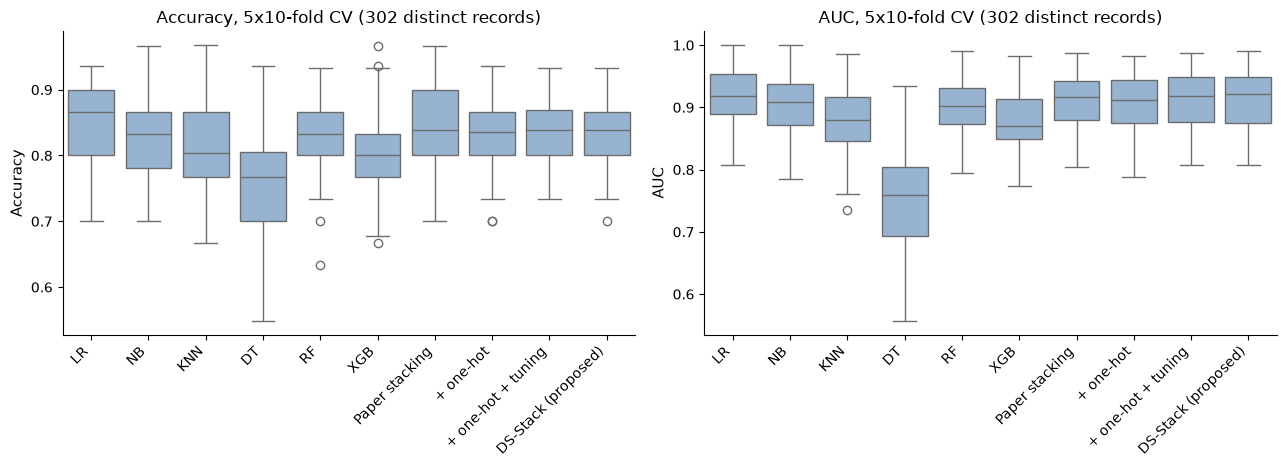

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, metric in zip(axes, ["Accuracy", "AUC"]):
    sns.boxplot(
        data=cv_scores,
        x="model",
        y=metric,
        order=ORDER,
        ax=ax,
        color=BOX_COLOR,
    )
    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")
    ax.set_xlabel("")
    ax.set_title(f"{metric}, 5x10-fold CV (302 distinct records)")
plt.tight_layout()
plt.savefig(FIGURES / "p2_cv_boxplot.png")
plt.show()

The boxes show variation across the same outer test folds. Overlapping boxes are useful
context, but the paired tests provide the statistical comparison.


### 3.6 Which base learners are selected?

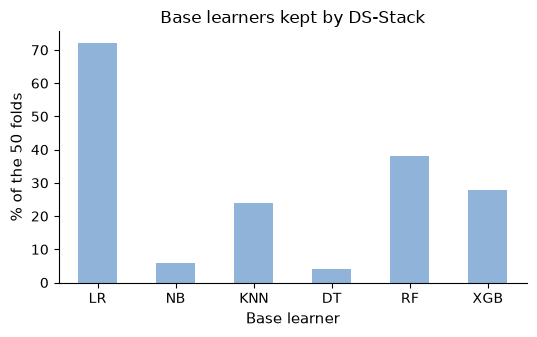

In [36]:
selection_counts = Counter()
proposed_rows = cv_scores[cv_scores["model"] == "DS-Stack (proposed)"]
for selected_names in proposed_rows["selected"]:
    selection_counts.update(selected_names.split("+"))
learner_names = ["LR", "NB", "KNN", "DT", "RF", "XGB"]
selection_frequency = pd.Series(selection_counts).reindex(learner_names)
selection_frequency = selection_frequency.fillna(0) / len(folds) * 100
selection_frequency.to_csv(
    RESULTS / "p2_selection_frequency.csv",
    header=["% of folds selected"],
)
ax = selection_frequency.plot.bar(
    color=BOX_COLOR,
    figsize=(5.5, 3.5),
    rot=0,
    title="Base learners kept by DS-Stack",
)
ax.set_ylabel("% of the 50 folds")
ax.set_xlabel("Base learner")
plt.tight_layout()
plt.savefig(FIGURES / "p2_selection_frequency.png")
plt.show()

LR is selected in 72% of folds and DT in 4%. Selection checks whether adding a learner
improves AUC; it does not calculate a separate diversity score.


### 3.7 Same models under different protocols

In [37]:
X_full, y_full = load_kaggle()
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=SEED
)


def train_leaky():
    """Compare both stacking models under the duplicate-heavy split."""
    models = {
        "Paper stacking": paper_stacking(),
        "DS-Stack (proposed)": DiversityStacking(),
    }
    result_rows = []
    for name, model in models.items():
        model_scores = fit_score(model, X_train, y_train, X_test, y_test)[0]
        model_scores["model"] = name
        result_rows.append(model_scores)
    return pd.DataFrame(result_rows)


leaky_scores = saved_or_train("p2_leaky_models.csv", train_leaky)
leaky_scores = leaky_scores.set_index("model")
baseline_cv = summary.loc["Paper stacking", (METRICS, "mean")].droplevel(1)
proposed_cv = summary.loc["DS-Stack (proposed)", (METRICS, "mean")].droplevel(1)
protocol_rows = {
    ("Paper reported", "Paper stacking"): PAPER.loc["Stacking", METRICS],
    ("Leaky 80/20 (1025 rows)", "Paper stacking"):
        leaky_scores.loc["Paper stacking", METRICS],
    ("Leaky 80/20 (1025 rows)", "DS-Stack"):
        leaky_scores.loc["DS-Stack (proposed)", METRICS],
    ("Leakage-free CV (302)", "Paper stacking"): baseline_cv,
    ("Leakage-free CV (302)", "DS-Stack"): proposed_cv,
}
protocol_comparison = pd.DataFrame(protocol_rows).T
protocol_comparison.to_csv(RESULTS / "p2_protocol_comparison.csv")
protocol_comparison

Accuracy  Precision  Recall      F1  \
Paper reported          Paper stacking    0.9853     1.0000  0.9727  0.9861   
Leaky 80/20 (1025 rows) Paper stacking    0.9854     1.0000  0.9709  0.9852   
                        DS-Stack          1.0000     1.0000  1.0000  1.0000   
Leakage-free CV (302)   Paper stacking    0.8397     0.8405  0.8757  0.8554   
                        DS-Stack          0.8364     0.8385  0.8760  0.8533   

                                           AUC  
Paper reported          Paper stacking  0.9880  
Leaky 80/20 (1025 rows) Paper stacking  1.0000  
                        DS-Stack        1.0000  
Leakage-free CV (302)   Paper stacking  0.9113  
                        DS-Stack        0.9106

Both deduplication and the evaluation protocol change in this comparison. The accuracy
difference cannot be attributed entirely to duplicates; the overlap audit and
seen/unseen results provide the direct evidence about that issue.


### 3.8 Missing measurements at other hospitals

In [38]:
missing_rates = {}
for hospital in ["hungarian", "switzerland", "va"]:
    hospital_features, _ = load_uci(hospital)
    missing_rates[hospital] = hospital_features.isna().mean()[
        ["slope", "ca", "thal", "chol"]
    ]
pd.DataFrame(missing_rates).round(2)

,hungarian,switzerland,va
slope,0.65,0.14,0.51
ca,0.99,0.96,0.99
thal,0.90,0.42,0.83
chol,0.08,1.00,0.28


Missing measurements vary across the three hospitals. This matters because a model
trained on Cleveland may face different amounts and patterns of missing data elsewhere.


### 3.9 External validation

In [39]:
def external_validation(name, model):
    """Train on Cleveland, then score the three other hospitals."""
    fitted_model = model.fit(X_unique, y_unique)
    result_rows = []
    for hospital in ["hungarian", "switzerland", "va"]:
        hospital_features, hospital_target = load_uci(hospital)
        probabilities = fitted_model.predict_proba(hospital_features)[:, 1]
        predictions = (probabilities >= 0.5).astype(int)
        hospital_scores = scores(hospital_target, predictions, probabilities)
        hospital_scores.update(
            model=name,
            site=hospital,
            n=len(hospital_target),
            prevalence_target1=hospital_target.mean(),
        )
        result_rows.append(hospital_scores)
    return result_rows


external_names = ["LR", "RF", "XGB", "Paper stacking", "DS-Stack (proposed)"]
external_models = {}
for name, model in candidates().items():
    if name in external_names:
        external_models[name] = model


def train_external_validation():
    """Collect external scores for the five selected models."""
    model_results = Parallel(n_jobs=N_JOBS)(
        delayed(external_validation)(name, model)
        for name, model in external_models.items()
    )
    result_rows = []
    for hospital_rows in model_results:
        result_rows.extend(hospital_rows)
    return pd.DataFrame(result_rows)


external_scores = saved_or_train(
    "p2_external_validation.csv", train_external_validation
)
external_scores.pivot(
    index="model", columns="site", values=["Accuracy", "AUC"]
).loc[list(external_models)]

Accuracy                          AUC                    
site                hungarian switzerland     va hungarian switzerland      va
model                                                                         
LR                     0.8027      0.7642  0.760    0.8673      0.7141  0.7509
RF                     0.8265      0.7561  0.735    0.8944      0.7462  0.7481
XGB                    0.7823      0.7317  0.755    0.8747      0.7380  0.7184
Paper stacking         0.8265      0.7967  0.750    0.8833      0.7446  0.7535
DS-Stack (proposed)    0.8367      0.7073  0.735    0.8934      0.7370  0.7504

The models are trained on Cleveland and tested on other hospitals. Stacking’s AUC is
lower there; in Hungary, DS-Stack has the highest accuracy and RF the highest AUC.
Switzerland has only eight no-disease records, making its AUC uncertain.


## Part 4 — Two further checks

Spline-LR adds smooth nonlinear numeric effects. MA-Ens averages LR, RF and
XGBoost after adding training copies with selected measurements hidden.
Augmentation stays within training data. Both approaches use the same outer folds.

In [40]:
X_unique, y_unique = load_kaggle(dedup=True)


def new_models():
    """Create Spline-LR and the two missingness-augmentation variants."""
    return {
        "Spline-LR": spline_lr(),
        "MA-Ens (no aug)": MissingnessAwareEnsemble(augment=False),
        "MA-Ens": MissingnessAwareEnsemble(),
    }

These extra comparisons test whether curved relationships or missing measurements help
explain the earlier result. The missingness-aware ensemble is tested both with and
without augmented training copies.


### 4.1 Spline and missingness-aware model implementations

In [41]:
SPLINE_COLS = ["age", "trestbps", "chol", "thalach", "oldpeak"]

MASKABLE = ["ca", "thal", "slope"]

def spline_lr(seed=SEED):
    """Add smooth numeric effects and choose LR regularisation by inner CV."""
    from sklearn.linear_model import LogisticRegressionCV
    from sklearn.preprocessing import SplineTransformer

    spline_pipeline = Pipeline(
        [
            ("s", SplineTransformer(n_knots=4, degree=3)),
            ("z", StandardScaler()),
        ]
    )
    encoder = ColumnTransformer(
        [
            ("spl", spline_pipeline, SPLINE_COLS),
            (
                "nom",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                NOMINAL,
            ),
            ("rest", StandardScaler(), BINARY + ["ca"]),
        ]
    )
    inner_cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    classifier = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 20),
        cv=inner_cv,
        scoring="roc_auc",
        max_iter=2000,
    )
    regression_imputer = IterativeImputer(
        estimator=LinearRegression(), random_state=SEED
    )
    return Pipeline(
        [
            ("invalid", InvalidCodesToNaN()),
            ("impute", regression_imputer),
            ("round", RoundCategorical()),
            ("encode", encoder),
            ("clf", classifier),
        ]
    )

Spline features let logistic regression model smooth, curved relationships in numerical
inputs. Its regularisation is chosen using cross-validation within the training data.


In [42]:
class MissingnessPrep(BaseEstimator, TransformerMixin):
    """Impute and encode features, then add indicators for missing tests."""

    def fit(self, X, y=None):
        cleaned_features = InvalidCodesToNaN().transform(X)
        self.imp_ = IterativeImputer(
            estimator=LinearRegression(), random_state=SEED
        ).fit(cleaned_features)
        self.enc_ = proposed_preprocessor().named_steps["encode"]
        imputed_features = self.imp_.transform(cleaned_features)
        rounded_features = RoundCategorical().transform(imputed_features)
        self.enc_.fit(rounded_features)
        return self

    def transform(self, X):
        cleaned_features = InvalidCodesToNaN().transform(X)
        # Record missingness before filling the measurements.
        missing_indicators = cleaned_features[MASKABLE].isna().astype(float)
        imputed_features = self.imp_.transform(cleaned_features)
        rounded_features = RoundCategorical().transform(imputed_features)
        encoded_features = self.enc_.transform(rounded_features)
        return np.hstack([encoded_features, missing_indicators.values])

Missing-value indicators record which measurements were absent before imputation. They
let the model use that information as well as the filled-in values.


In [43]:
class MissingnessAwareEnsemble(BaseEstimator, ClassifierMixin):
    """Average LR, RF and XGB predictions after training with missing-test copies."""

    def __init__(self, seed=SEED, augment=True):
        self.seed = seed
        self.augment = augment

    def _augment(self, X, y):
        cleaned_features = InvalidCodesToNaN().transform(X)
        feature_parts = [cleaned_features]
        target_parts = [np.asarray(y)]
        if self.augment:
            for hidden_columns in (["ca", "thal"], MASKABLE):
                masked_copy = cleaned_features.copy()
                masked_copy[hidden_columns] = np.nan
                feature_parts.append(masked_copy)
                target_parts.append(np.asarray(y))
        augmented_features = pd.concat(feature_parts, ignore_index=True)
        augmented_target = np.concatenate(target_parts)
        return augmented_features, augmented_target

    def fit(self, X, y):
        augmented_features, augmented_target = self._augment(X, y)
        cleaned_features = InvalidCodesToNaN().transform(X)
        self.prep_ = MissingnessPrep().fit(cleaned_features)
        encoded_features = self.prep_.transform(augmented_features)
        classifiers = [
            LogisticRegression(C=0.3, max_iter=2000),
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=5,
                random_state=self.seed,
                n_jobs=1,
            ),
            XGBClassifier(
                n_estimators=200,
                max_depth=2,
                learning_rate=0.05,
                subsample=0.8,
                eval_metric="logloss",
                random_state=self.seed,
                n_jobs=1,
            ),
        ]
        self.models_ = []
        for classifier in classifiers:
            classifier.fit(encoded_features, augmented_target)
            self.models_.append(classifier)
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        encoded_features = self.prep_.transform(X)
        probability_columns = []
        for model in self.models_:
            probability_columns.append(model.predict_proba(encoded_features)[:, 1])
        target_probabilities = np.mean(probability_columns, axis=0)
        return np.column_stack([1 - target_probabilities, target_probabilities])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

The ensemble averages LR, RF and XGBoost probabilities. Augmentation adds training
copies with selected measurements hidden; it stays within training data and does not add
copies to the test fold.


### 4.2 Compare on the same 50 folds

In [44]:
outer_cv = RepeatedStratifiedKFold(
    n_splits=10, n_repeats=5, random_state=SEED
)
folds = list(outer_cv.split(X_unique, y_unique))


def run_extra_fold(fold_number, train_indices, test_indices):
    """Score the extra models on the same outer fold as the baselines."""
    result_rows = []
    for name, model in new_models().items():
        model_scores = fit_score(
            model,
            X_unique.iloc[train_indices],
            y_unique.iloc[train_indices],
            X_unique.iloc[test_indices],
            y_unique.iloc[test_indices],
        )[0]
        model_scores.update(model=name, fold=fold_number)
        result_rows.append(model_scores)
    return result_rows


def train_extra_cv():
    """Collect the extra-model scores over the same 50 folds."""
    fold_results = Parallel(n_jobs=N_JOBS)(
        delayed(run_extra_fold)(fold_number, train_indices, test_indices)
        for fold_number, (train_indices, test_indices) in enumerate(folds)
    )
    result_rows = []
    for fold_rows in fold_results:
        result_rows.extend(fold_rows)
    return pd.DataFrame(result_rows)


extra_scores = saved_or_train("p2b_new_cv_raw.csv", train_extra_cv)
baseline_names = ["LR", "Paper stacking", "DS-Stack (proposed)"]
previous_scores = pd.read_csv(RESULTS / "p2_cv_raw.csv")
baseline_rows = previous_scores[previous_scores["model"].isin(baseline_names)]
cv_scores = pd.concat([baseline_rows, extra_scores], ignore_index=True)
cv_scores.to_csv(RESULTS / "p2b_cv_raw.csv", index=False)
ORDER = [
    "Paper stacking", "LR", "DS-Stack (proposed)",
    "Spline-LR", "MA-Ens (no aug)", "MA-Ens",
]
summary = cv_scores.groupby("model")[METRICS + ["MCC"]].agg(
    ["mean", "std"]
).loc[ORDER]
summary.to_csv(RESULTS / "p2b_cv_summary.csv")
summary

Accuracy         Precision          Recall          \
                        mean     std      mean     std    mean     std   
model                                                                    
Paper stacking        0.8397  0.0631    0.8405  0.0672  0.8757  0.0790   
LR                    0.8476  0.0592    0.8365  0.0679  0.9024  0.0765   
DS-Stack (proposed)   0.8364  0.0520    0.8385  0.0692  0.8760  0.0743   
Spline-LR             0.8344  0.0650    0.8320  0.0735  0.8793  0.0833   
MA-Ens (no aug)       0.8364  0.0591    0.8341  0.0691  0.8804  0.0792   
MA-Ens                0.8285  0.0575    0.8281  0.0636  0.8707  0.0835   

                         F1             AUC             MCC          
                       mean     std    mean     std    mean     std  
model                                                                
Paper stacking       0.8554  0.0577  0.9113  0.0479  0.6807  0.1289  
LR                   0.8654  0.0521  0.9142  0.0454  0.6992  0.1204  
DS-Stack (proposed)  0.8533  0.0458  0.9106  0.0466  0.6765  0.1054  
Spline-LR            0.8519  0.0598  0.9089  0.0512  0.6713  0.1313  
MA-Ens (no aug)      0.8536  0.0534  0.9120  0.0432  0.6756  0.1204  
MA-Ens               0.8457  0.0537  0.9028  0.0483  0.6597  0.1161

The extra models use the same 50 folds as the earlier comparison. Neither additional
approach improves the observed mean accuracy or AUC over stacking.


### 4.3 Corrected comparisons

In [45]:
test_count = len(folds[0][1])
training_count = len(folds[0][0])
test_rows = []
for reference_name in ["Paper stacking", "LR"]:
    reference_scores = cv_scores[
        cv_scores["model"] == reference_name
    ].sort_values("fold")
    for model_name in ["Spline-LR", "MA-Ens (no aug)", "MA-Ens"]:
        candidate_scores = cv_scores[
            cv_scores["model"] == model_name
        ].sort_values("fold")
        for metric in ["Accuracy", "AUC", "F1"]:
            candidate_values = candidate_scores[metric].to_numpy()
            reference_values = reference_scores[metric].to_numpy()
            differences = candidate_values - reference_values
            _, p_value = corrected_ttest(
                candidate_values, reference_values, training_count, test_count
            )
            wilcoxon_p = 1.0
            if np.any(differences != 0):
                wilcoxon_p = wilcoxon(differences).pvalue
            test_rows.append(
                {
                    "model": model_name,
                    "vs": reference_name,
                    "metric": metric,
                    "mean diff": differences.mean(),
                    "p (corrected t)": p_value,
                    "p (Wilcoxon)": wilcoxon_p,
                }
            )
significance_results = pd.DataFrame(test_rows)
significance_results.to_csv(RESULTS / "p2b_significance.csv", index=False)
significance_results

,model,vs,metric,mean diff,p (corrected t),p (Wilcoxon)
0,Spline-LR,Paper stacking,Accuracy,-0.0053,0.7785,0.5604
1,Spline-LR,Paper stacking,AUC,-0.0025,0.8121,0.5315
2,Spline-LR,Paper stacking,F1,-0.0035,0.8369,0.6814
3,MA-Ens (no aug),Paper stacking,Accuracy,-0.0033,0.8497,0.7058
4,MA-Ens (no aug),Paper stacking,AUC,0.0007,0.9308,0.8991
5,MA-Ens (no aug),Paper stacking,F1,-0.0019,0.9020,0.8381
6,MA-Ens,Paper stacking,Accuracy,-0.0112,0.5130,0.1320
7,MA-Ens,Paper stacking,AUC,-0.0086,0.3854,0.0261
8,MA-Ens,Paper stacking,F1,-0.0097,0.5204,0.0738
9,Spline-LR,LR,Accuracy,-0.0132,0.3884,0.0270


The corrected comparisons do not establish an improvement over stacking. These results
do not prove the methods are equivalent or rule out gains on other data.


### 4.4 Showing the fold distributions

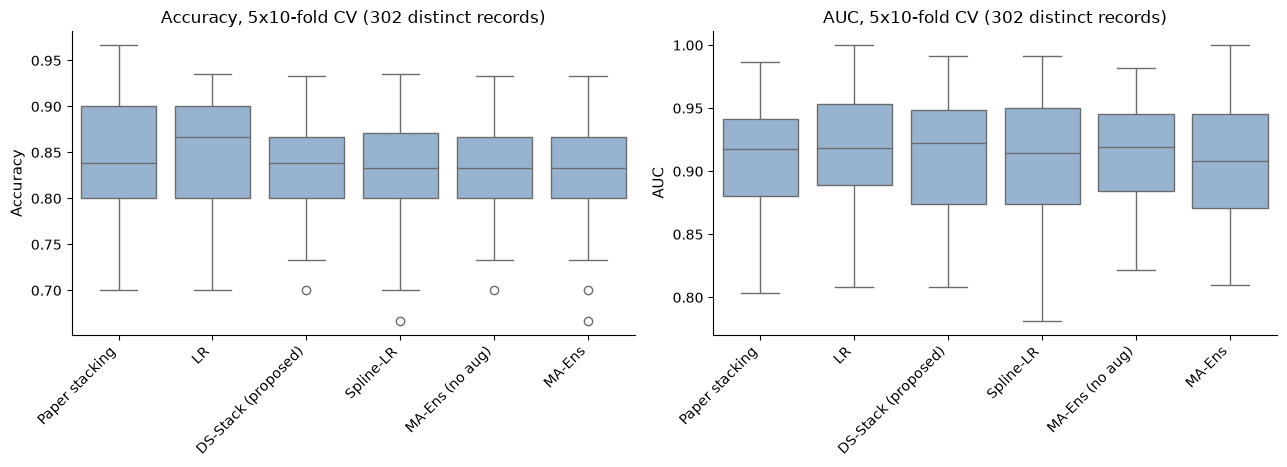

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, metric in zip(axes, ["Accuracy", "AUC"]):
    sns.boxplot(
        data=cv_scores,
        x="model",
        y=metric,
        order=ORDER,
        ax=ax,
        color=BOX_COLOR,
    )
    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")
    ax.set_xlabel("")
    ax.set_title(f"{metric}, 5x10-fold CV (302 distinct records)")
plt.tight_layout()
plt.savefig(FIGURES / "p2b_cv_boxplot.png")
plt.show()

The plots show how the extra models’ scores vary across folds alongside the earlier
models. A good result on one fold does not establish a consistent improvement.


### 4.5 Transfer to other hospitals

In [47]:
def train_extra_external():
    """Collect external scores for Spline-LR and both MA variants."""
    model_results = Parallel(n_jobs=N_JOBS)(
        delayed(external_validation)(name, model)
        for name, model in new_models().items()
    )
    result_rows = []
    for hospital_rows in model_results:
        result_rows.extend(hospital_rows)
    extra_external_scores = pd.DataFrame(result_rows)
    return extra_external_scores.drop(columns=["n", "prevalence_target1"])


extra_external_scores = saved_or_train(
    "p2b_new_external_validation.csv", train_extra_external
)
previous_external_scores = pd.read_csv(RESULTS / "p2_external_validation.csv")
baseline_rows = previous_external_scores[
    previous_external_scores["model"].isin(baseline_names)
]
external_scores = pd.concat(
    [baseline_rows, extra_external_scores], ignore_index=True
)
external_scores.to_csv(RESULTS / "p2b_external_validation.csv", index=False)
external_scores.pivot(
    index="model", columns="site", values=["Accuracy", "AUC"]
).loc[ORDER]

Accuracy                          AUC                    
site                hungarian switzerland     va hungarian switzerland      va
model                                                                         
Paper stacking         0.8265      0.7967  0.750    0.8833      0.7446  0.7535
LR                     0.8027      0.7642  0.760    0.8673      0.7141  0.7509
DS-Stack (proposed)    0.8367      0.7073  0.735    0.8934      0.7370  0.7504
Spline-LR              0.8265      0.7642  0.725    0.8768      0.7739  0.7398
MA-Ens (no aug)        0.8299      0.7642  0.715    0.8940      0.7554  0.7456
MA-Ens                 0.8197      0.7561  0.730    0.8941      0.7826  0.7390

This comparison checks whether the extra methods transfer to the three other hospitals.
Any apparent advantage needs to be considered alongside uncertainty and the differences
between hospitals.


### 4.6 Bootstrap intervals for external AUC differences

In [48]:
bootstrap_models = {
    "Paper stacking": paper_stacking(),
    "MA-Ens": MissingnessAwareEnsemble(),
    "Spline-LR": spline_lr(),
}
fitted_bootstrap_models = {}
for name, model in bootstrap_models.items():
    fitted_bootstrap_models[name] = model.fit(X_unique, y_unique)

random_generator = np.random.default_rng(SEED)
bootstrap_rows = []
for hospital in ["hungarian", "va"]:
    hospital_features, hospital_target = load_uci(hospital)
    hospital_target = hospital_target.to_numpy()
    hospital_probabilities = {}
    for name, model in fitted_bootstrap_models.items():
        hospital_probabilities[name] = model.predict_proba(hospital_features)[:, 1]

    for model_name in ["MA-Ens", "Spline-LR"]:
        auc_differences = []
        for bootstrap_number in range(2000):
            sample_indices = random_generator.integers(
                0, len(hospital_target), len(hospital_target)
            )
            sampled_target = hospital_target[sample_indices]
            if sampled_target.min() == sampled_target.max():
                continue  # AUC needs both classes in the resampled test set.
            candidate_auc = roc_auc_score(
                sampled_target,
                hospital_probabilities[model_name][sample_indices],
            )
            baseline_auc = roc_auc_score(
                sampled_target,
                hospital_probabilities["Paper stacking"][sample_indices],
            )
            auc_differences.append(candidate_auc - baseline_auc)
        auc_differences = np.asarray(auc_differences)
        bootstrap_rows.append(
            {
                "site": hospital,
                "model": model_name,
                "AUC diff vs paper stacking": auc_differences.mean(),
                "95% CI low": np.percentile(auc_differences, 2.5),
                "95% CI high": np.percentile(auc_differences, 97.5),
            }
        )
bootstrap_results = pd.DataFrame(bootstrap_rows)
bootstrap_results.to_csv(RESULTS / "p2b_external_bootstrap.csv", index=False)
bootstrap_results

/Users/rex/Documents/Study_Mat/Y2/T2/SIT307/111HD/code/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:2071: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/rex/Documents/Study_Mat/Y2/T2/SIT307/111HD/code/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:2129: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressio

,site,model,AUC diff vs paper stacking,95% CI low,95% CI high
0,hungarian,MA-Ens,0.0109,-0.0025,0.0245
1,hungarian,Spline-LR,-0.0067,-0.0206,0.0061
2,va,MA-Ens,-0.0146,-0.0346,0.0059
3,va,Spline-LR,-0.0136,-0.0417,0.0135


MA-Ens gains about 0.011 AUC in Hungary, but its 95% interval includes zero. The
bootstrap resamples test records with fitted models held fixed, so it does not include
uncertainty from retraining on a different Cleveland sample.


## Part 5 — Conclusion and limitations

The reproduction matches the paper's headline accuracy, but duplicate overlap
makes it a poor estimate for unseen records. After deduplication, stacking
averages about 84% accuracy. DS-Stack and the extra models do not establish a gain;
plain logistic regression remains a strong baseline.

The study has only 302 distinct Cleveland records, a limited tuning search and
external hospitals with different missing-data patterns. These results do not
establish a performance ceiling. Larger independent datasets are needed.

## Sources

1. M. Bhagat, A. Sharma and P. Agarwal, “An efficient stacking-based ensemble
   technique for early heart attack prediction,” *Multimedia Tools and Applications*,
   vol. 84, pp. 36351–36375, 2025.
   [Selected paper](https://doi.org/10.1007/s11042-024-19293-7).
2. D. Lapp (johnsmith88), “Heart Disease Dataset,” Kaggle, 2019.
   [Kaggle dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset).
3. A. Janosi, W. Steinbrunn, M. Pfisterer and R. Detrano, “Heart Disease,”
   UCI Machine Learning Repository, 1989.
   [UCI dataset](https://doi.org/10.24432/C52P4X).
4. D. H. Wolpert, “Stacked generalization,” *Neural Networks*, vol. 5, no. 2,
   pp. 241–259, 1992. [Stacking](https://doi.org/10.1016/S0893-6080(05)80023-1).
5. C. Nadeau and Y. Bengio, “Inference for the generalization error,”
   *Machine Learning*, vol. 52, pp. 239–281, 2003.
   [Corrected test](https://doi.org/10.1023/A:1024068626366).
6. R. Caruana, A. Niculescu-Mizil, G. Crew and A. Ksikes,
   “Ensemble selection from libraries of models,” *ICML*, 2004.
   [Learner-selection inspiration](https://doi.org/10.1145/1015330.1015432).

## Acknowledgement of GenAI use

Generative AI (Claude and Codex) was used in an open and acknowledged way for this task. I used it to help
structure the notebook and the report and to fix the grammar and wording of my writing. I also
used AI code assistance while writing the code here. I reviewed and ran everything myself, checked
the outputs against the data, and made sure I understand and can explain each part. The analysis,
decisions and conclusions are my own.